In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import models, layers
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import joblib
import numpy as np

In [4]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Fruit_Fresh_pro/dataset_split/train/mango",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "C:/Fruit_Fresh_pro/dataset_split/val/mango",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# ✅ Print class names (label mapping)
print("Class labels:", train_ds.class_names)

train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds   = val_ds.map(lambda x, y: (x/255.0, y))

Found 3600 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Class labels: ['good', 'premium', 'rotten']


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(128,128,3))

x = layers.Conv2D(32, (3,3), padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(64, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.Conv2D(128, (3,3), padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D(2,2)(x)

x = layers.GlobalAveragePooling2D()(x)

features = layers.Dense(128, activation='relu', name="features")(x)
features = layers.BatchNormalization()(features)
features = layers.Dropout(0.4)(features)

outputs = layers.Dense(3, activation='softmax')(features)

cnn_classifier = Model(inputs, outputs)

In [4]:
cnn_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history = cnn_classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15)

Epoch 1/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 70s 567ms/step - accuracy: 0.7061 - loss: 0.7315 - val_accuracy: 0.3333 - val_loss: 1.2452
Epoch 2/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 560ms/step - accuracy: 0.7814 - loss: 0.5384 - val_accuracy: 0.3333 - val_loss: 1.5078
Epoch 3/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 83s 566ms/step - accuracy: 0.8478 - loss: 0.4179 - val_accuracy: 0.3389 - val_loss: 1.4168
Epoch 4/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 561ms/step - accuracy: 0.8617 - loss: 0.3728 - val_accuracy: 0.6444 - val_loss: 0.7865
Epoch 5/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 82s 562ms/step - accuracy: 0.8803 - loss: 0.3244 - val_accuracy: 0.7467 - val_loss: 0.5418
Epoch 6/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 565ms/step - accuracy: 0.8875 - loss: 0.3024 - val_accuracy: 0.8200 - val_loss: 0.4711
Epoch 7/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 81s 559ms/step - accuracy: 0.8958 - loss: 0.2865 - val_accuracy: 0.8756 - val_loss: 0.3384
Epoch 8/15
113/113 ━━━━━━━━━━━━━━━━━━━━ 64s 561ms/step - accuracy: 0.9008 - loss: 0

In [7]:
cnn_classifier.save("C:/Fruit_Fresh_pro/model/mango_cnn.h5")

In [7]:
from tensorflow.keras.models import load_model
cnn_classifier = load_model("C:/Fruit_Fresh_pro/model/mango_cnn.h5")

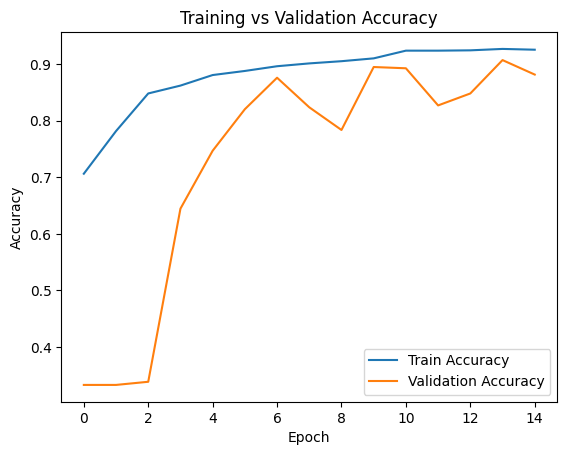

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

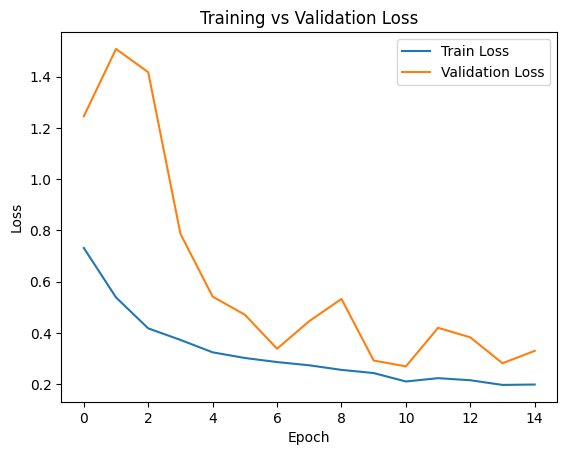

In [9]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [10]:
cnn_classifier.trainable = False

In [12]:
cnn_feature_extractor = Model(
    inputs=cnn_classifier.input,
    outputs=cnn_classifier.get_layer("features").output
)

In [15]:
import numpy as np

def extract_features(ds):
    X, y = [], []
    for images, labels in ds:
        feats = cnn_feature_extractor(images, training=False)
        X.append(feats.numpy())
        y.append(labels.numpy())
    return np.vstack(X), np.concatenate(y)

X_train, y_train = extract_features(train_ds)
X_val, y_val     = extract_features(val_ds)

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

svm = LinearSVC(C=1.0)
svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [17]:
y_pred = svm.predict(X_val)

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm.predict(X_val)

print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       300
           1       0.95      0.93      0.94       300
           2       0.96      0.87      0.91       300

    accuracy                           0.92       900
   macro avg       0.93      0.92      0.92       900
weighted avg       0.93      0.92      0.92       900

[[294   4   2]
 [ 14 278   8]
 [ 30  10 260]]


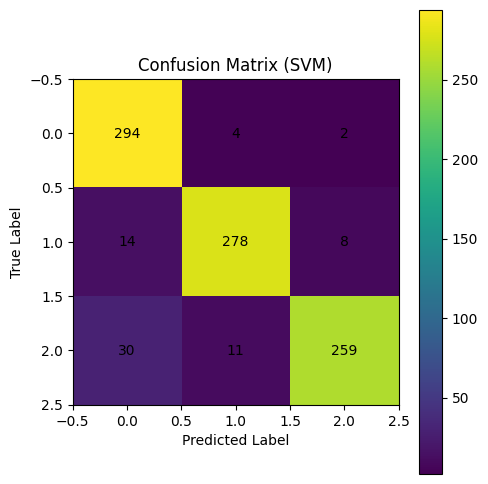

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm)
plt.title("Confusion Matrix (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import accuracy_score

y_pred = svm.predict(X_val)
hybrid_acc = accuracy_score(y_val, y_pred)

print("Hybrid CNN + SVM Accuracy:",round(hybrid_acc * 100),"%")

Hybrid CNN + SVM Accuracy: 92 %


In [18]:
from joblib import dump

# svm_model = your trained SVM
dump(svm, "C:/Fruit_Fresh_pro/model/svm_model_new.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!


In [9]:
from joblib import load

svm_model = load("C:/Fruit_Fresh_pro/model/mango_svm.pkl")

print("SVM model loaded successfully!")

SVM model loaded successfully!


In [27]:
from joblib import dump

dump(scaler, "C:/Fruit_Fresh_pro/model/mango_scaler.pkl")
print("Scaler saved!")

Scaler saved!


In [10]:
from PIL import Image
import numpy as np

def extract_features_from_image(img_path, img_size=128):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img = np.array(img) / 255.0

    img = np.expand_dims(img, axis=0)   # (1, 128, 128, 3)

    features = cnn_feature_extractor(img, training=False)
    return features.numpy()


In [24]:
img_path = r"C:/Fruit_Fresh_pro/random/mango/pngtree-rot-mango-fruit-on-white-background-inedible-picture-image_13263239.png"

features = extract_features_from_image(img_path)
print(features.shape)

(1, 128)


In [25]:
img_scaled   = scaler.transform(features)

In [26]:
prediction = svm_model.predict(img_scaled)
print(prediction)

[2]


In [25]:
import os
random_folder = r"C:/Fruit_Fresh_pro/random"

for file in os.listdir(random_folder):
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(random_folder, file)

        # 1️⃣ Extract CNN features
        features = extract_features_from_image(img_path)
        print(f"{file} → feature shape:", features.shape)

        # 2️⃣ Scale features
        img_scaled = scaler.transform(features)

        # 3️⃣ SVM prediction
        prediction = svm_model.predict(img_scaled)[0]

        # 4️⃣ Print result
        print(f"{file} → Predicted class: {prediction}")
        print("-" * 50)

good.jpg → feature shape: (1, 128)
good.jpg → Predicted class: 0
--------------------------------------------------
grp.jpg → feature shape: (1, 128)
grp.jpg → Predicted class: 2
--------------------------------------------------
premium.jpg → feature shape: (1, 128)
premium.jpg → Predicted class: 1
--------------------------------------------------
rot.jpg → feature shape: (1, 128)
rot.jpg → Predicted class: 2
--------------------------------------------------
rott.jpg → feature shape: (1, 128)
rott.jpg → Predicted class: 2
--------------------------------------------------
rottt.jpg → feature shape: (1, 128)
rottt.jpg → Predicted class: 2
--------------------------------------------------
